In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset("titanic")

features = ["pclass" , "sex" , "fare" , "embarked" , "age"]

target=["survived"]

#handle missing values

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

#encode

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


X=titanic[features]
y=titanic[target]

#train test split
X_train , X_test,y_train , y_test = train_test_split (
    X,y,test_size=0.3,random_state=42)

In [3]:
model = DecisionTreeClassifier()

model.fit(X_train , y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("test accuracy:",accuracy_score(y_test , y_pred_test)*100,"%")
print("train accuracy:",accuracy_score(y_train , y_pred_train)*100,"%")

test accuracy: 76.11940298507463 %
train accuracy: 97.91332263242376 %


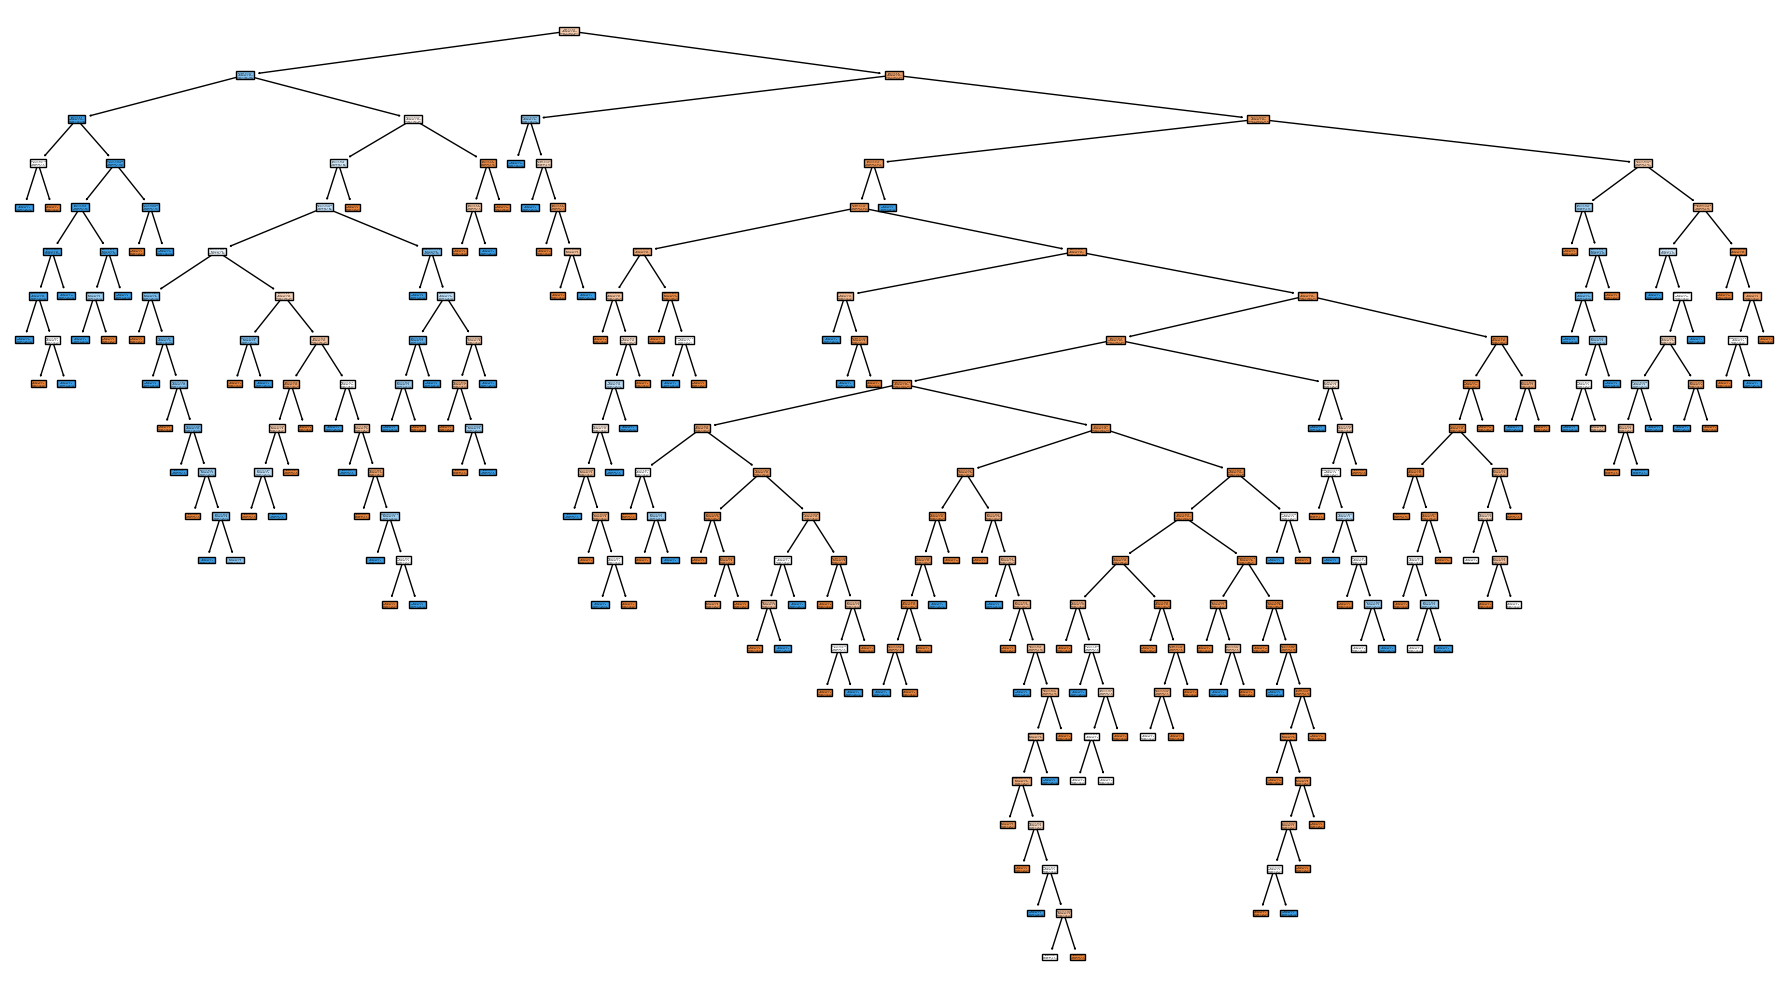

In [4]:

from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(

    model ,
    feature_names=X.columns , 
    class_names=["Died" , "Survived"],
    filled=True
)


plt.tight_layout()

In [5]:
# random forest


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=201 ,
    oob_score=True,
    bootstrap=True
)


rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

print("testing accuracy:" , accuracy_score(y_test , y_pred))
print("oob accuracy:" , rf.oob_score_ * 100)



C:\Users\vaish\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


testing accuracy: 0.7723880597014925
oob accuracy: 81.2199036918138


In [6]:
 # bagging classifier 


from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(

    base_model , 
    n_estimators=201

)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("accuraccy:" , accuracy_score (y_test, y_pred))

C:\Users\vaish\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuraccy: 0.7649253731343284


In [7]:
#for logistic regression

 # bagging classifier 


from sklearn.linear_model import LogisticRegression

base_model =  LogisticRegression(max_iter=10000)

bagging = BaggingClassifier(

    base_model , 
    n_estimators=201

)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("accuraccy:" , accuracy_score (y_test, y_pred))

C:\Users\vaish\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


accuraccy: 0.7947761194029851
